OpenCV library : # pip install opencv-python

In [ ]:
%pip install opencv-python matplotlib
print("hey")
arr = [2,4,6,8]
for i in range(len(arr)):
    print(arr[i])

Import Template (No Defects) picture first

In [3]:
import cv2 
import matplotlib.pyplot as plt
import os

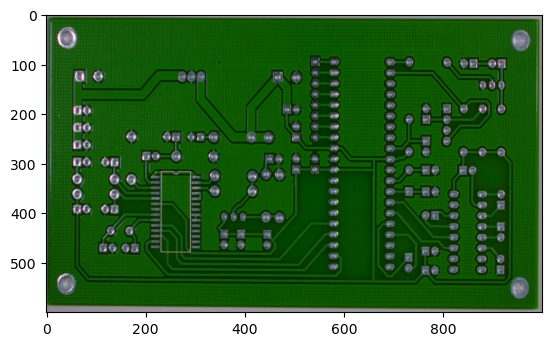

In [9]:
# read img (template)
rgb_img_template = cv2.imread("image.png")

# resized and display
new_width= 1000
new_height= 600
new_dims = (new_width,new_height)
resized_img = cv2.resize(rgb_img_template,new_dims,interpolation = cv2.INTER_AREA)

#display
plt.imshow(resized_img,cmap='gray')

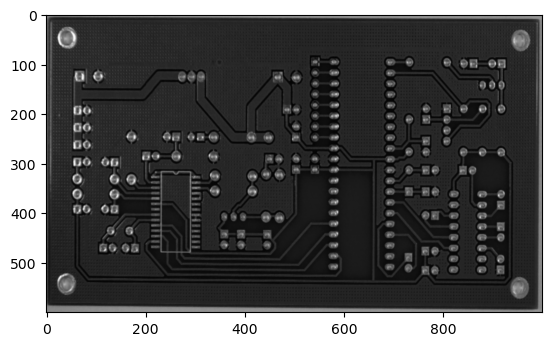

In [14]:
# It's work well! Reread the img as gray scale and then
# blur to reduce noise before threshold considering
gray_img_template = cv2.imread("image.png",0)
resized_gray_img = cv2.resize(gray_img_template,new_dims)
blurred_gray_img_template = cv2.GaussianBlur(resized_gray_img,(3,3),0) # Spread blurness of center pieces related by S.D.
plt.imshow(blurred_gray_img_template, cmap="gray")

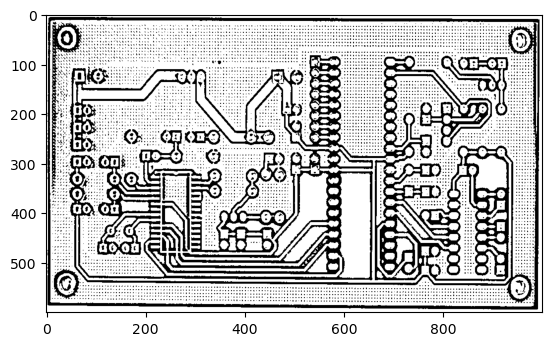

In [16]:
# use Adaptive threshold to turn gray scale to binary bit mask
blurred_img_adaptive = cv2.adaptiveThreshold(blurred_gray_img_template, 255, 
                                         cv2. ADAPTIVE_THRESH_MEAN_C,
                                         cv2.THRESH_BINARY, 15, 5)

plt.imshow(blurred_img_adaptive, cmap="gray")

Now Import the defected one.

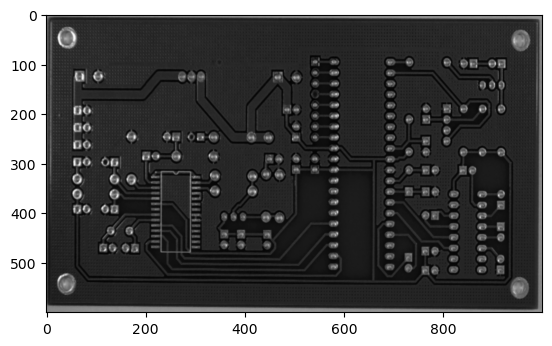

In [32]:
# read img in gray scale
gray_defected_img = cv2.imread("image_copy.png",0)
resized_gray_defected = cv2.resize(gray_defected_img,new_dims)
blurred_gray_defected = cv2.GaussianBlur(resized_gray_defected,(3,3),0)
plt.imshow(blurred_gray_defected, cmap="gray")

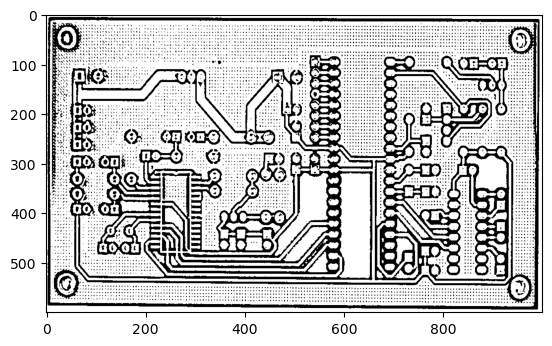

In [33]:
# use Adaptive threshold to turn gray scale to binary bit mask
blurred_defected_adaptive = cv2.adaptiveThreshold(blurred_gray_defected, 255, 
                                         cv2. ADAPTIVE_THRESH_MEAN_C,
                                         cv2.THRESH_BINARY, 15, 5)
plt.imshow(blurred_defected_adaptive,cmap='gray')

Image Subtraction

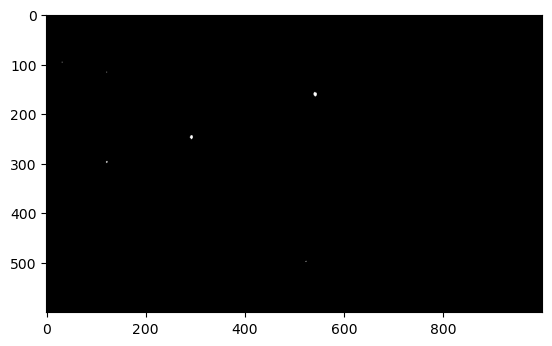

In [38]:
# Image subtraction
sub_img= cv2.subtract(blurred_img_adaptive, blurred_defected_adaptive)
polished_img = cv2.medianBlur(sub_img,3)
plt.imshow(polished_img,cmap='gray')